In [1]:
# Import pandas to read dataset
import pandas as pd

In [2]:
#  Create DataFrame from Dataset
df = pd.read_csv("../../data/insurance_data.csv")

In [3]:
# Display first 5 rows of dataframe
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Display information about Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Check for missing values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Display useful analytics of the data
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


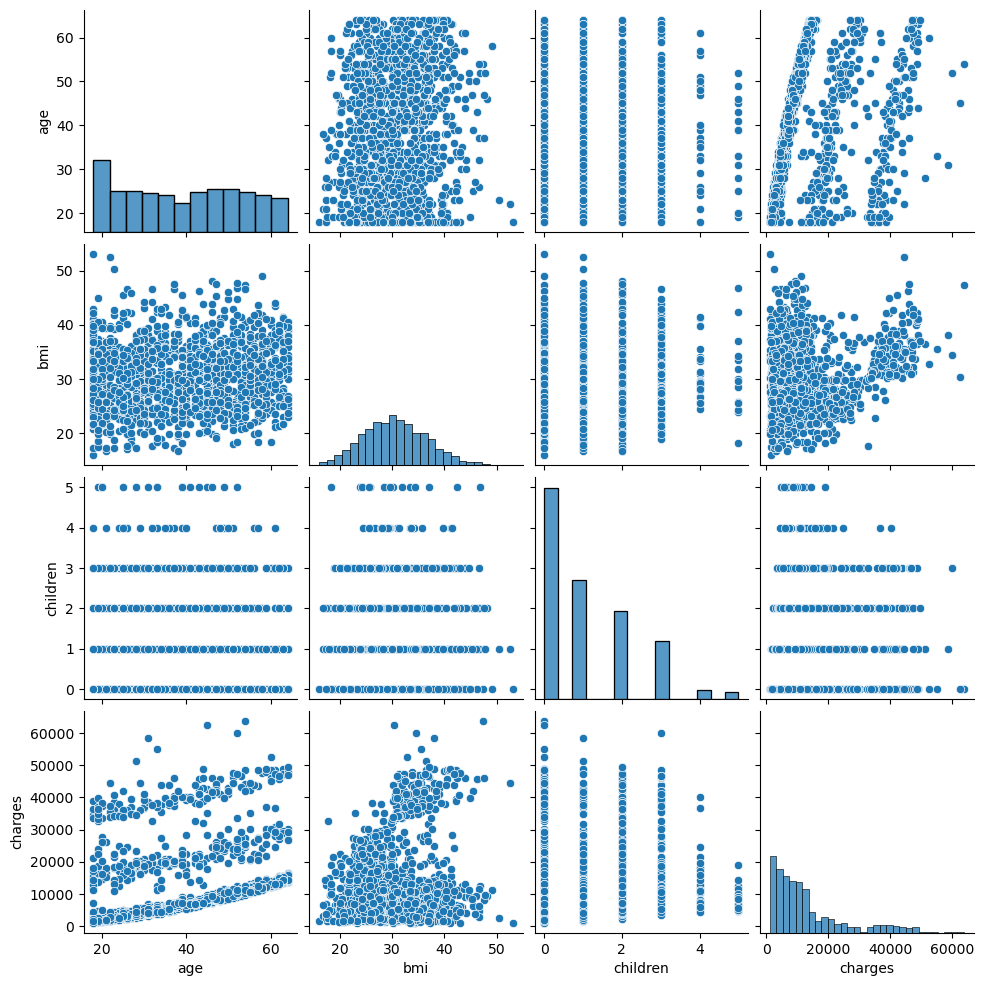

In [8]:
# Import seaborn and matplotlib to plot correlation of all features against one another
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.savefig("../../figures/eda/insurance/correlation_plot_for_all_features.png")
plt.show()

In [10]:
import warnings
warnings.filterwarnings("ignore")

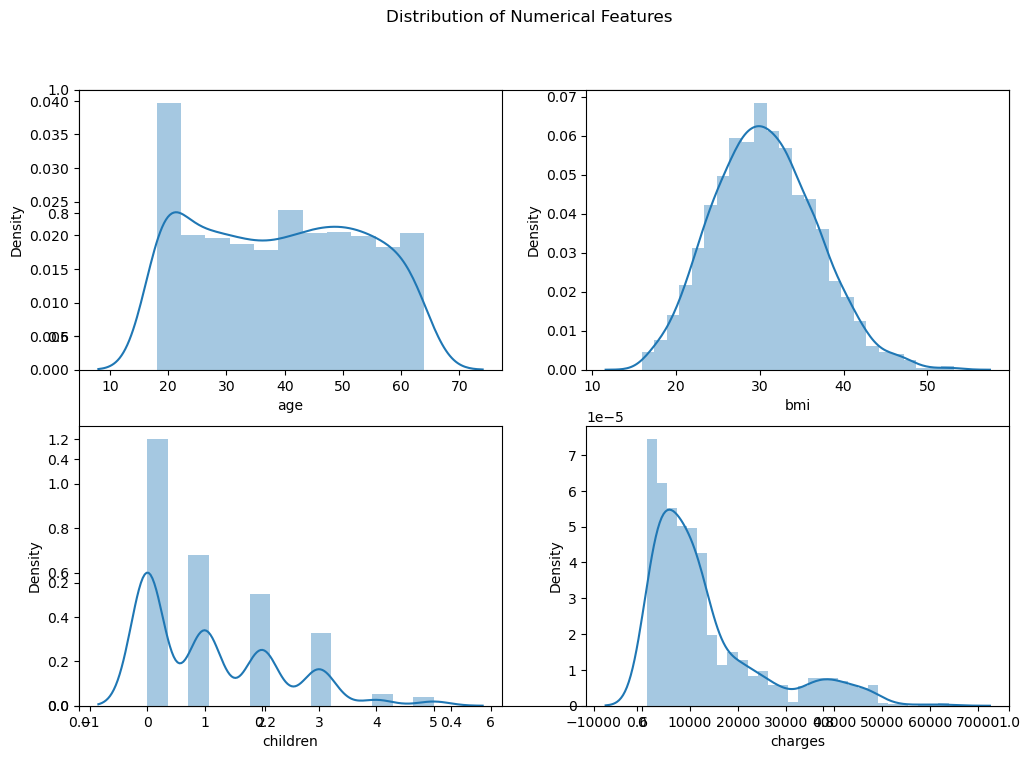

In [11]:
# Display and save Density plot for numerical columns
plt.subplots(figsize = (12, 8))
for i, col in enumerate(df.select_dtypes(exclude = 'object').columns, 1):
    plt.subplot(2, 2, i)
    sns.distplot(df[col])
plt.suptitle('Distribution of Numerical Features')
plt.savefig("../../figures/eda/insurance/density_plots_for_numerical_features.png")
plt.show()

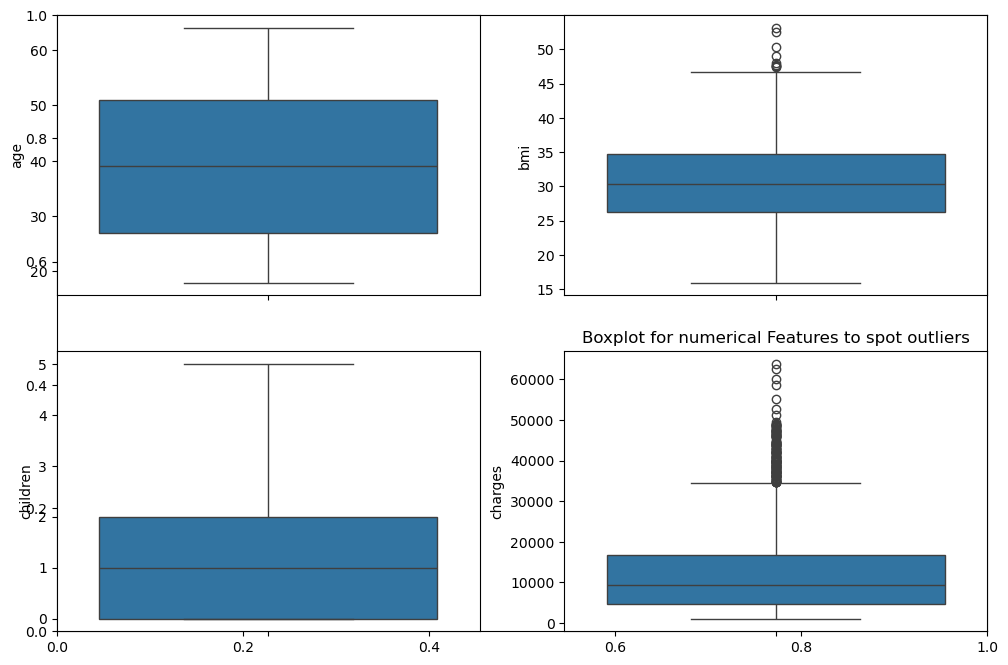

In [13]:
# Display and save Boxplot for numerical features to spot outliers in the data
plt.subplots(figsize = (12, 8))
for i, col in enumerate(df.select_dtypes(exclude = "object").columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(df[col])
plt.title("Boxplot for numerical Features to spot outliers")
plt.savefig("../../figures/eda/insurance/boxplot_for_numerical_features.png")
plt.show()

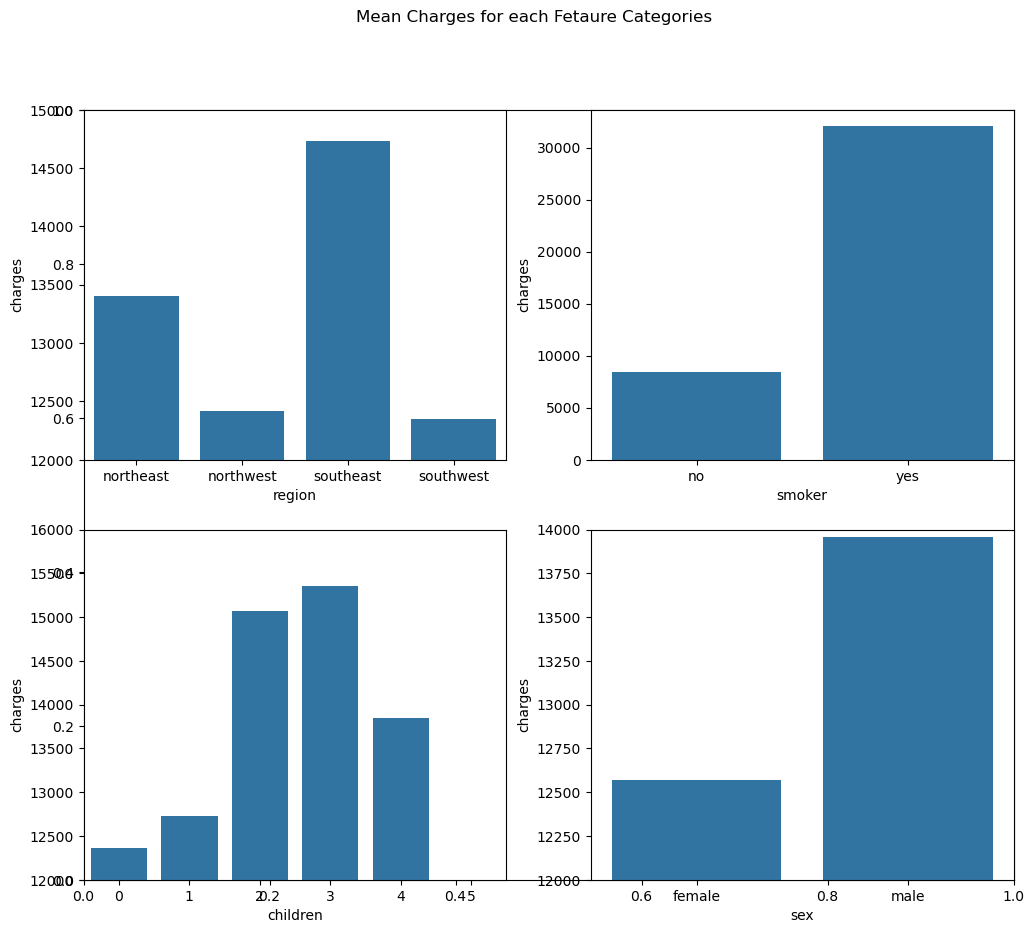

In [17]:
# Dictionary storing y-axis limits
ylims = {"region": 15000,
"sex": 14000,
"children": 16000}

# Display and save the mean charges for each feeature categories
plt.subplots(figsize = (12, 10))
for i, col in enumerate(["region", "smoker", "children", "sex"], 1):
    plt.subplot(2, 2, i)
    sns.barplot(x = df.groupby(col)["charges"].mean().index, y = df.groupby(col)["charges"].mean())
    if col!= "smoker":
        plt.ylim(12000, ylims[col])
plt.suptitle("Mean Charges for each Fetaure Categories")
plt.savefig("../../figures/eda/insurance/mean_charge_for_each_unique_feature_categories.png")
plt.show()

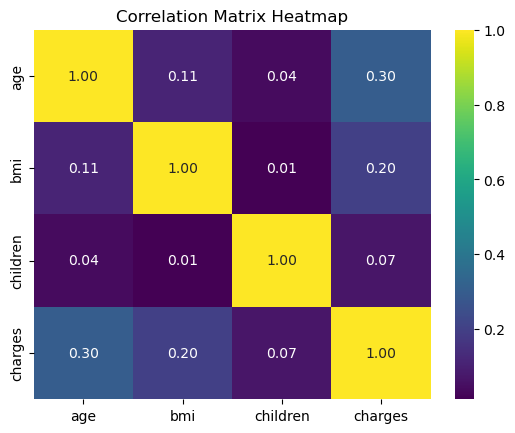

In [16]:
# Create correlation matrix from dataset
corr = df.corr(numeric_only = True) 
# Display and save the heatmap of the correlation matrix
sns.heatmap(corr, annot = True, cmap = "viridis", fmt = ".2f")
plt.title('Correlation Matrix Heatmap')
plt.savefig("../../figures/eda/insurance/heatmap_of_correlation_matrix_of_dataset.png")
plt.show()

In [18]:
# Import tool for splitting dataset into Training and Testing sets
from sklearn.model_selection import train_test_split

In [19]:
# Split the dataset
df_train, df_test = train_test_split(df, test_size = .2, random_state = 42)

In [20]:
# Import preprocessing pipeline tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [21]:
# Initialize list of numericl and categorical column names for preprocessing
num_cols = df.select_dtypes(exclude = "object").drop(columns ="charges").columns
cat_cols = df.select_dtypes(include = "object").columns

In [50]:
# Import array tool and initialize preprocessing pipeline
import numpy as np
num_pipeline = Pipeline([
    ("scaler", StandardScaler()),
                        ])
cat_pipeline = Pipeline([("onehot", OneHotEncoder()),
                        ('scaler', StandardScaler(with_mean = False))])

preprocessor = ColumnTransformer([("num", num_pipeline, num_cols),
                                 ("cat", cat_pipeline, cat_cols)])

X_train = df_train.drop(columns ="charges")
X_test = df_test.drop(columns = "charges")
y_train = np.array(df_train["charges"])
y_test = np.array(df_test["charges"])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)



In [23]:
# Import Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [25]:
# Dictionary store of model names, estimators and parameters for hyperparameter tuning
models = [("lr", LinearRegression(), {
    'fit_intercept': [True, False],
    'positive': [True, False] # Forces coefficients to be positive
}),
         ("rf", RandomForestRegressor(), {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] # None uses all features
}),
         ("svr", SVR(), {
    'kernel': ['rbf', 'poly', 'linear'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 'auto'] # Important for 'rbf' and 'poly'
}),
         ("xgb", XGBRegressor(), {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
})]

In [26]:
# Import tools for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [27]:
# Initialize tuning process
tuned_models = {}
for model_name, model, params in models:
    search = GridSearchCV(model, param_grid = params, cv = 4, scoring = "neg_mean_absolute_error")
    search.fit(X_train, y_train)
    tuned_models[model_name] = search.best_params_, search.best_score_
    print(model_name, search.best_score_)

lr -4245.804076847801
rf -2688.731880226442
svr -3494.2693018132773
xgb -2572.86661332369


In [28]:
# Store parameters for best_performing model
params = tuned_models["xgb"][0]

In [29]:
# Initialize best performing model with stored parameters
model = XGBRegressor(**params)

In [30]:
# Train Model
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
# Predict on testing set
preds = model.predict(X_test)

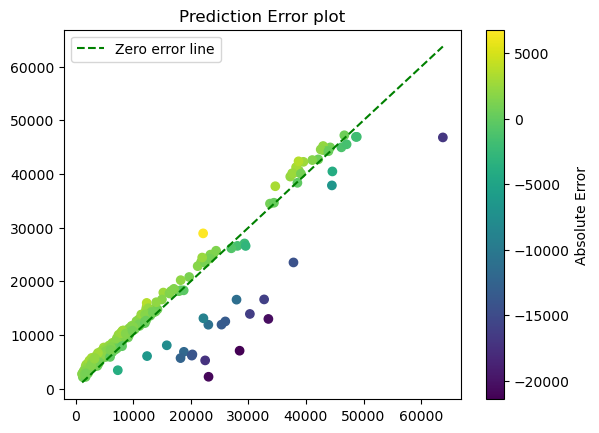

In [80]:
# Display and save plot visualizing model prediction error
errors = preds - y_test
plt.scatter(x = y_test, y = preds, c = errors, cmap = "viridis")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "g--", label = "Zero error line")
plt.colorbar(label = "Absolute Error")
plt.legend()
plt.title("Prediction Error plot")
plt.savefig("../../figures/results/insurance/model_prediction_error_plot.png")
plt.show()

In [32]:
# Display MAE SCore
from sklearn.metrics import mean_absolute_error as mae
print(mae(preds, y_test))

2453.6112364162195


In [34]:
# Conclusion: An MAE Score of 2453 
# indicates that our model was fairly good at predicting medical insurance charges with little error.